# Complete Single-Stage Run: Midpoint Geometry

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, '../../..')
sys.path.insert(0, '../..')
sys.path.insert(0, '.')

plt.style.use('../../../configurations/style.mplstyle')
datafiles           = Path('../../../datafiles')
baseline_filenames  = "../Output_files/baseline_flat_midpoint_alpha"
possible_alpha      = ["A0.5", "A1.0", "A3.0", "A5.0"]
baseline_paths      = {a : Path(f"{baseline_filenames}_{a}/emcee.h5") for a in possible_alpha}
for value in baseline_paths.values(): assert value.is_file(), f"File {value} does not exist."

from src.top_hat.geometric_eff import geometric_efficiency_flat_midpoint, geometric_efficiency_fixed, create_geometric_efficiency_lognormal_interpolator

print('Imports complete.')

Imports complete.


In [3]:
import emcee
fixed_params = {}
for alpha in possible_alpha:
    #test_backend    = baseline_paths["A5.0"]
    test_backend        = baseline_paths.get(alpha)
    samples             = emcee.backends.HDFBackend(test_backend).get_chain(flat=True, discard=3000, thin = 10)
    mu_e                = samples[:, 2]
    sigma_e             = samples[:, 3]
    e_vals, s_vals      = np.percentile(mu_e, [50, 5, 95]), np.percentile(sigma_e, [50, 5, 95])
    med_e, e_05, e_95   = e_vals
    med_s, s_05, s_95   = s_vals
    #print(f"Alpha: {alpha} | L_mu_E: {med_e:.3f} [{e_05:.3f}, {e_95:.3f}] | sigma_E: {med_s:.3f} [{s_05:.3f}, {s_95:.3f}]")
    A_index = samples[:, 0]
    log_values = emcee.backends.HDFBackend(test_backend).get_log_prob(flat=True, discard=3000, thin = 10)
    #maximum_log_value = np.max(log_values)
    #only take values with A < 3
    maximum_log_value = np.max(log_values[A_index < 3])
    max_indices = np.where(log_values == maximum_log_value)[0]
    max_e = mu_e[max_indices][0]
    
    max_s = sigma_e[max_indices][0]
    max_A = A_index[max_indices][0]
    print(f"Maximum log-probability: {maximum_log_value:.2f} at A={max_A:.2f}, L_mu_E={max_e:.2f}, sigma_E={max_s:.2f}")
    fixed_params[alpha] = {"L_mu_E": max_e, "sigma_E": max_s, "A_index": max_A}

Maximum log-probability: -4.18 at A=3.00, L_mu_E=3.35, sigma_E=0.37
Maximum log-probability: -3.92 at A=2.74, L_mu_E=3.32, sigma_E=0.31
Maximum log-probability: -4.38 at A=2.77, L_mu_E=3.31, sigma_E=0.34
Maximum log-probability: -4.15 at A=2.96, L_mu_E=3.40, sigma_E=0.42


In [ ]:
# Run configuration
from mcmc_runner_a import run_pop_a
geom_eff_func_mp           = geometric_efficiency_flat_midpoint
geom_eff_func_fixed         = geometric_efficiency_fixed
geom_eff_func_lognormal     = create_geometric_efficiency_lognormal_interpolator()

geom_eff_func = geom_eff_func_fixed

nsbh_population_soft    = "fiducial_delayed_cut_sfho" # sfho
nsbh_population_hard    = "fiducial_delayed_cut_dd2" # dd2
nsbh_populations        = [nsbh_population_soft, nsbh_population_hard]
# Run the single complete MC chain for all alphas.
local_rate_dicts        = []
FJ_BNS                  = 1
for nsbh_pop in nsbh_populations:
    output, dict_rates = run_pop_a(
        alphas          =   possible_alpha,
        geom_eff_func   =   geom_eff_func,
        datafiles       =   datafiles,
        fixed_params    =   fixed_params,
        nsbh_population =   nsbh_pop,
        FJ_BNS          =   FJ_BNS,
    )
    local_rate_dicts.append(dict_rates)

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 19248.6 yr^-1 (local R_0 = 3.9 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A0.5
  BHNSs local rate R_0 = 3.9 Gpc^-3 yr^-1
  BHNSs total rate     = 19249 yr^-1
  1-year z sample size = 19248
Creating new directory : Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_fixed_sfho
Grid tensor computed for alpha A0.5.
Results archived at: Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_fixed_sfho/grid_eval.npz
Using redshift model: samples_fiducial_delayed_A1.0_BNSs_0.dat with 342071 BNSs.
Compute

Loading existing directory  : Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_fixed_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_fixed_dd2
Maximum log-likelihood value: -4.8873335241772615
Maximum log-likelihood value: -4.887991844655497


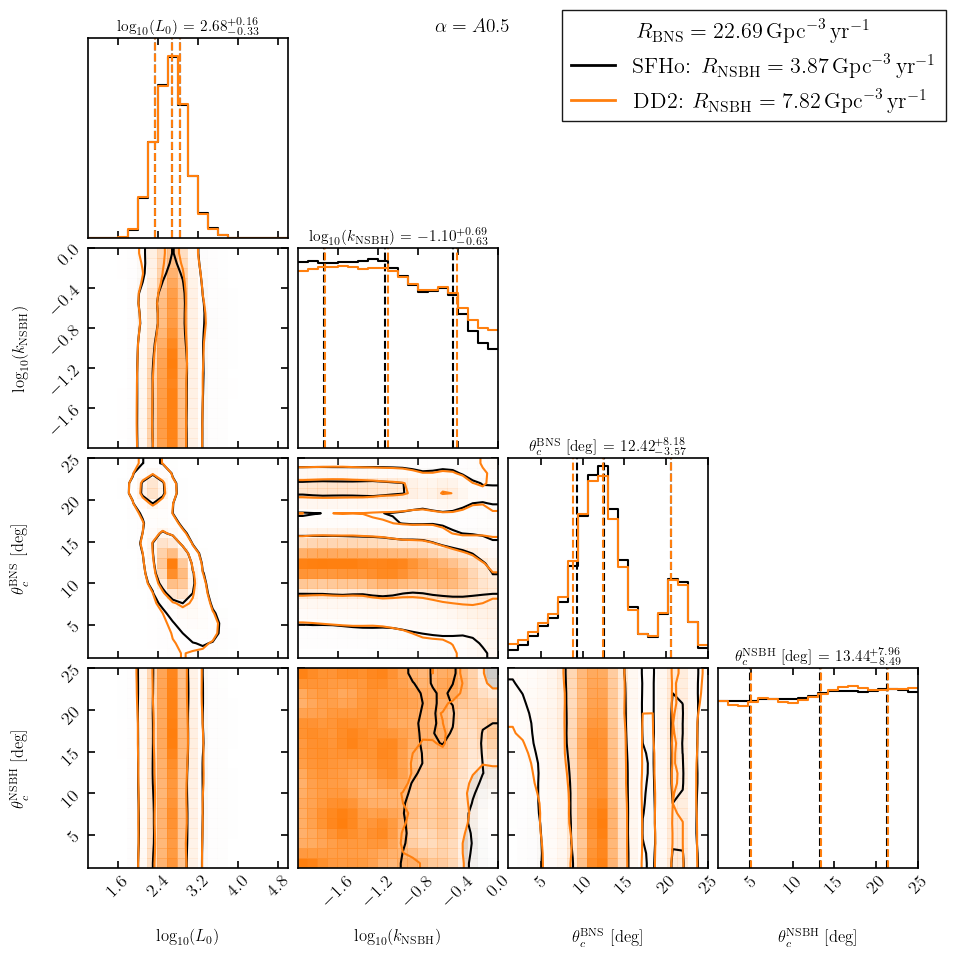

Loading existing directory  : Output_files/grid_likelihood_alpha_A1.0_1_geometric_efficiency_fixed_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A1.0_1_geometric_efficiency_fixed_dd2
Maximum log-likelihood value: -5.046203014439594
Maximum log-likelihood value: -5.025835333212308


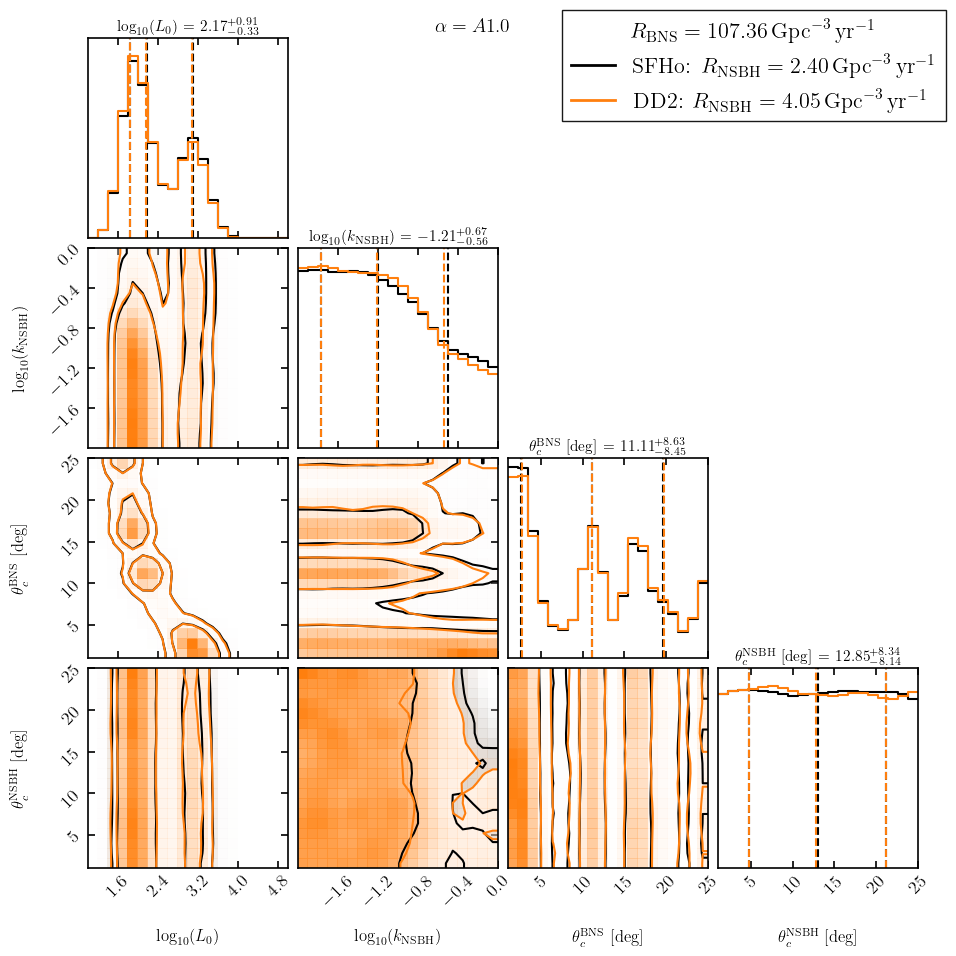

Loading existing directory  : Output_files/grid_likelihood_alpha_A3.0_1_geometric_efficiency_fixed_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A3.0_1_geometric_efficiency_fixed_dd2
Maximum log-likelihood value: -4.008343310082001
Maximum log-likelihood value: -4.008304611724544


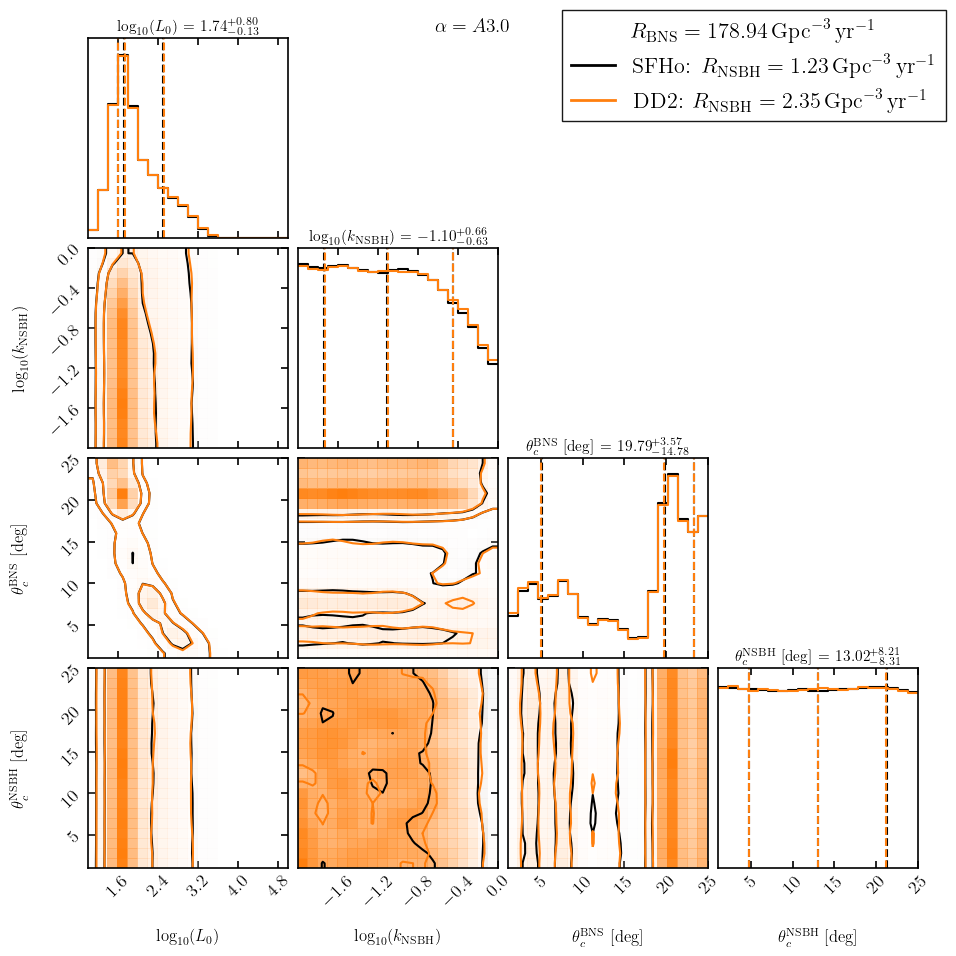

Loading existing directory  : Output_files/grid_likelihood_alpha_A5.0_1_geometric_efficiency_fixed_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A5.0_1_geometric_efficiency_fixed_dd2
Maximum log-likelihood value: -5.059846530812278
Maximum log-likelihood value: -5.059945769713208


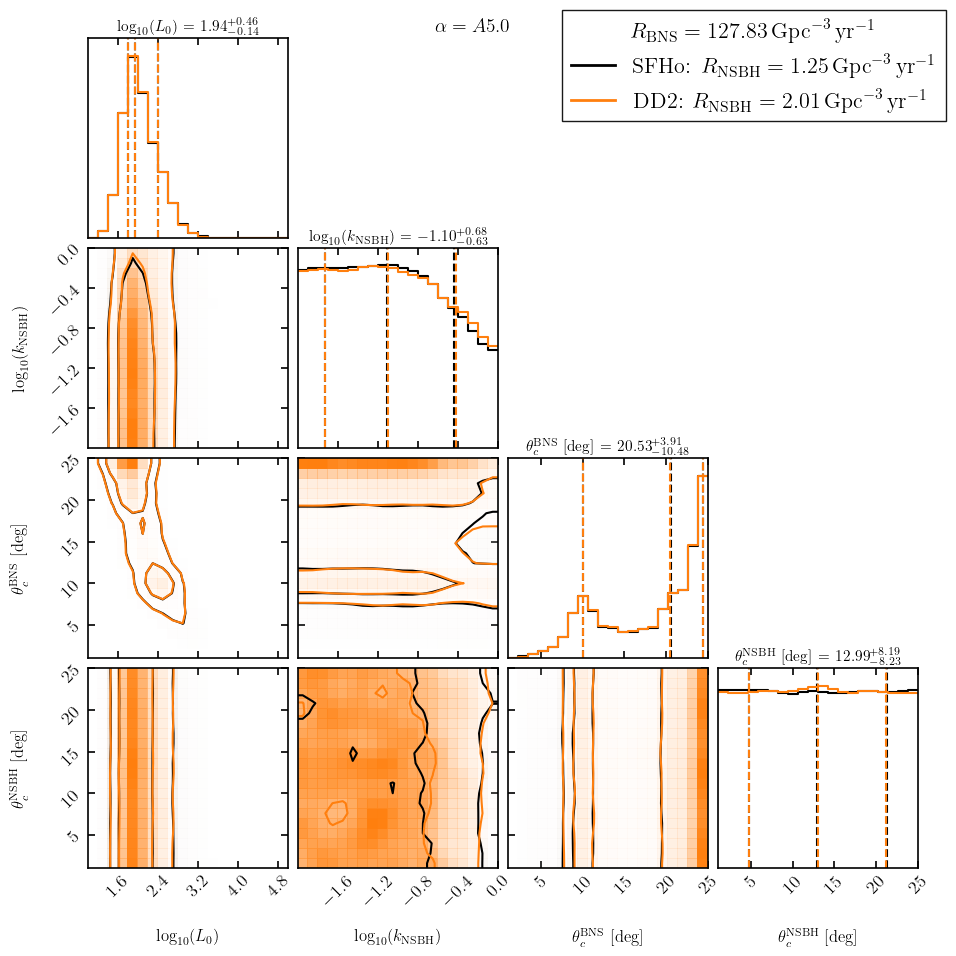

In [4]:
from mcmc_runner_a import plot_corner_grid_multiples
plot_corner_grid_multiples(alphas=possible_alpha, 
                           local_rate_dicts=local_rate_dicts, 
                           FJ_BNS=FJ_BNS,
                           nsbh_populations=nsbh_populations, 
                           geom_eff_func=geom_eff_func)

Loading existing directory  : Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_fixed_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_fixed_dd2
Maximum log-likelihood value: -4.8873335241772615
Maximum log-likelihood value: -4.887991844655497
Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 19248.6 yr^-1 (local R_0 = 3.9 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A0.5
  BHNSs local rate R_0 = 3.9 Gpc^-3 yr^-1
  BHNSs total rate     = 19249 yr^-1
  1-year z sample size = 19248


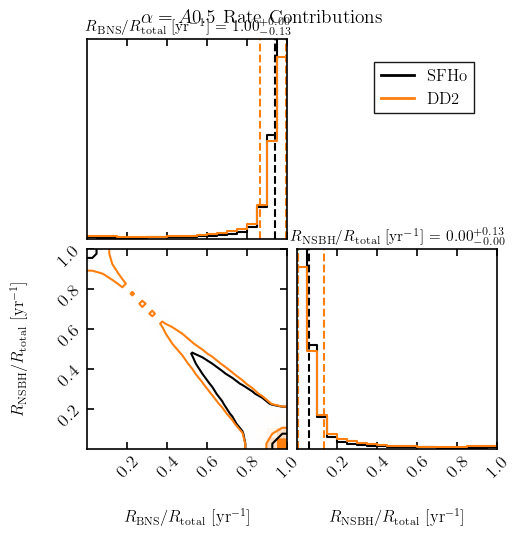

Loading existing directory  : Output_files/grid_likelihood_alpha_A1.0_1_geometric_efficiency_fixed_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A1.0_1_geometric_efficiency_fixed_dd2
Maximum log-likelihood value: -5.046203014439594
Maximum log-likelihood value: -5.025835333212308
Using redshift model: samples_fiducial_delayed_A1.0_BNSs_0.dat with 342071 BNSs.
Computed total merger rate: 343741.1 yr^-1 (local R_0 = 107.4 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 11743.4 yr^-1 (local R_0 = 2.4 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A1.0
  BHNSs local rate R_0 = 2.4 Gpc^-3 yr^-1
  BHNSs total rate     = 11743 yr^-1
  1-year z sample size = 11743


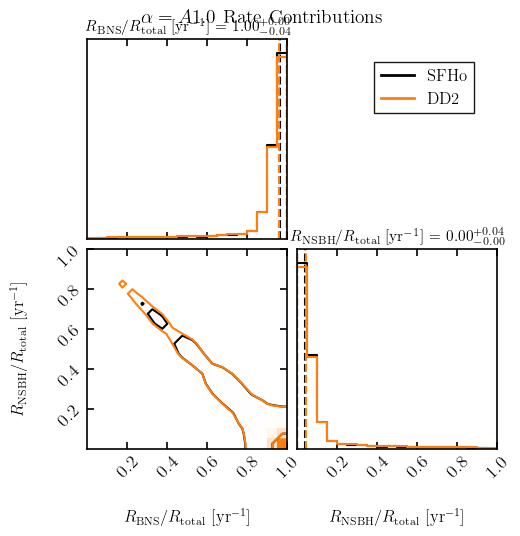

Loading existing directory  : Output_files/grid_likelihood_alpha_A3.0_1_geometric_efficiency_fixed_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A3.0_1_geometric_efficiency_fixed_dd2
Maximum log-likelihood value: -4.008343310082001
Maximum log-likelihood value: -4.008304611724544
Using redshift model: samples_fiducial_delayed_A3.0_BNSs_0.dat with 358417 BNSs.
Computed total merger rate: 360097.8 yr^-1 (local R_0 = 178.9 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 5191.6 yr^-1 (local R_0 = 1.2 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A3.0
  BHNSs local rate R_0 = 1.2 Gpc^-3 yr^-1
  BHNSs total rate     = 5192 yr^-1
  1-year z sample size = 5191


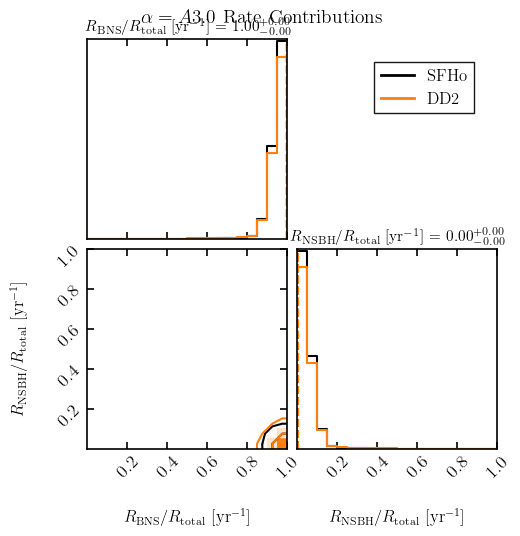

Loading existing directory  : Output_files/grid_likelihood_alpha_A5.0_1_geometric_efficiency_fixed_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A5.0_1_geometric_efficiency_fixed_dd2
Maximum log-likelihood value: -5.059846530812278
Maximum log-likelihood value: -5.059945769713208
Using redshift model: samples_fiducial_delayed_A5.0_BNSs_0.dat with 136203 BNSs.
Computed total merger rate: 136874.3 yr^-1 (local R_0 = 127.8 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 4322.7 yr^-1 (local R_0 = 1.2 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A5.0
  BHNSs local rate R_0 = 1.2 Gpc^-3 yr^-1
  BHNSs total rate     = 4323 yr^-1
  1-year z sample size = 4322


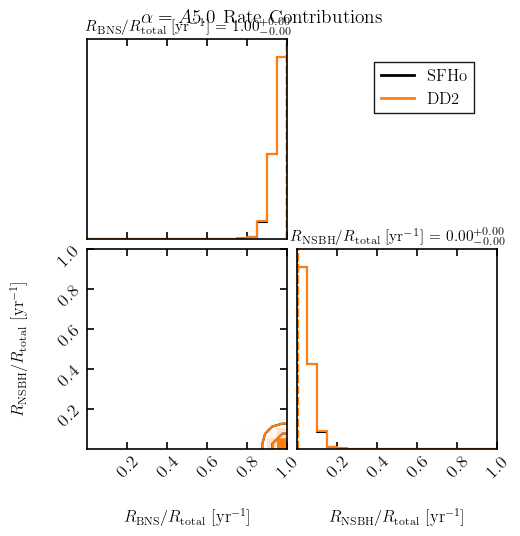

In [5]:
from mcmc_runner_a import posterior_rate_contribution_corner_plot
posterior_rate_contribution_corner_plot(alphas=possible_alpha, 
                                        local_rate_dicts=local_rate_dicts, 
                                        nsbh_populations=nsbh_populations, 
                                        FJ_BNS=FJ_BNS,
                                        geom_eff_func=geom_eff_func)

In [ ]:
1/0

ZeroDivisionError: division by zero

In [9]:
# Run configuration
from mcmc_runner_a import run_pop_a
geom_eff_func_midpoint          = geometric_efficiency_flat_midpoint
geom_eff_func_fixed             = geometric_efficiency_fixed
geom_eff_func_interp            = create_geometric_efficiency_lognormal_interpolator()
def geom_eff_func_lognormal(x): return geom_eff_func_interp(x)
nsbh_population_soft            = "fiducial_delayed_cut_sfho" # sfho
nsbh_population_hard            = "fiducial_delayed_cut_dd2" # dd2
nsbh_populations                = [nsbh_population_soft, nsbh_population_hard]

#geom_eff_func = geom_eff_func_lognormal
#geom_eff_func = geom_eff_func_fixed
geom_eff_func = geom_eff_func_midpoint

# Execution loop for different FJ_BNS values
fj_list = [0.01]#, 0.1]#, 0.5, 1.0]
possible_alpha = ["A0.5", "A1.0"]
results_by_fj = {}

for fj in fj_list:
    grid_files_by_population = []
    local_rate_dicts = []
    for nsbh_pop in nsbh_populations:
        output, dict_rates = run_pop_a(
            alphas=possible_alpha,
            geom_eff_func=geom_eff_func,
            datafiles=datafiles,
            fixed_params=fixed_params,
            nsbh_population=nsbh_pop,
            FJ_BNS=fj,
        )
        grid_files_by_population.append(output)
        local_rate_dicts.append(dict_rates)
    results_by_fj[fj] = {
        "grid_files": grid_files_by_population,
        "local_rate_dicts": local_rate_dicts,
    }

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 19248.6 yr^-1 (local R_0 = 3.9 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A0.5
  BHNSs local rate R_0 = 3.9 Gpc^-3 yr^-1
  BHNSs total rate     = 19249 yr^-1
  1-year z sample size = 19248
Creating new directory : Output_files/grid_likelihood_alpha_A0.5_0.01_geometric_efficiency_flat_midpoint_sfho
Grid tensor computed for alpha A0.5.
Results archived at: Output_files/grid_likelihood_alpha_A0.5_0.01_geometric_efficiency_flat_midpoint_sfho/grid_eval.npz
Using redshift model: samples_fiducial_delayed_A1.0_BNSs_0.dat wit

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 19248.6 yr^-1 (local R_0 = 3.9 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A0.5
  BHNSs local rate R_0 = 3.9 Gpc^-3 yr^-1
  BHNSs total rate     = 19249 yr^-1
  1-year z sample size = 19248
Maximum log-likelihood value: -4.887333124514765
Maximum log-likelihood value: -4.887990898610363
Maximum log-likelihood value: -4.8873470231865035
Maximum log-likelihood value: -4.8879925770944315
Maximum log-likelihood value: -4.887333059311668
Maximum log-likelihood value: -4.887990802987227
Using redshift model: samples_fiducia

(<Figure size 1200x800 with 6 Axes>,
 array([[<Axes: title={'center': '$\\alpha=A0.5$ | $f_{j}=0.3$'}, ylabel='$R_{\\rm NSBH}\\,[\\mathrm{yr}^{-1}]$'>,
         <Axes: title={'center': '$\\alpha=A0.5$ | $f_{j}=0.5$'}>,
         <Axes: title={'center': '$\\alpha=A0.5$ | $f_{j}=1.0$'}>],
        [<Axes: title={'center': '$\\alpha=A1.0$ | $f_{j}=0.3$'}, xlabel='$R_{\\rm BNS}\\,[\\mathrm{yr}^{-1}]$', ylabel='$R_{\\rm NSBH}\\,[\\mathrm{yr}^{-1}]$'>,
         <Axes: title={'center': '$\\alpha=A1.0$ | $f_{j}=0.5$'}, xlabel='$R_{\\rm BNS}\\,[\\mathrm{yr}^{-1}]$'>,
         <Axes: title={'center': '$\\alpha=A1.0$ | $f_{j}=1.0$'}, xlabel='$R_{\\rm BNS}\\,[\\mathrm{yr}^{-1}]$'>]],
       dtype=object))

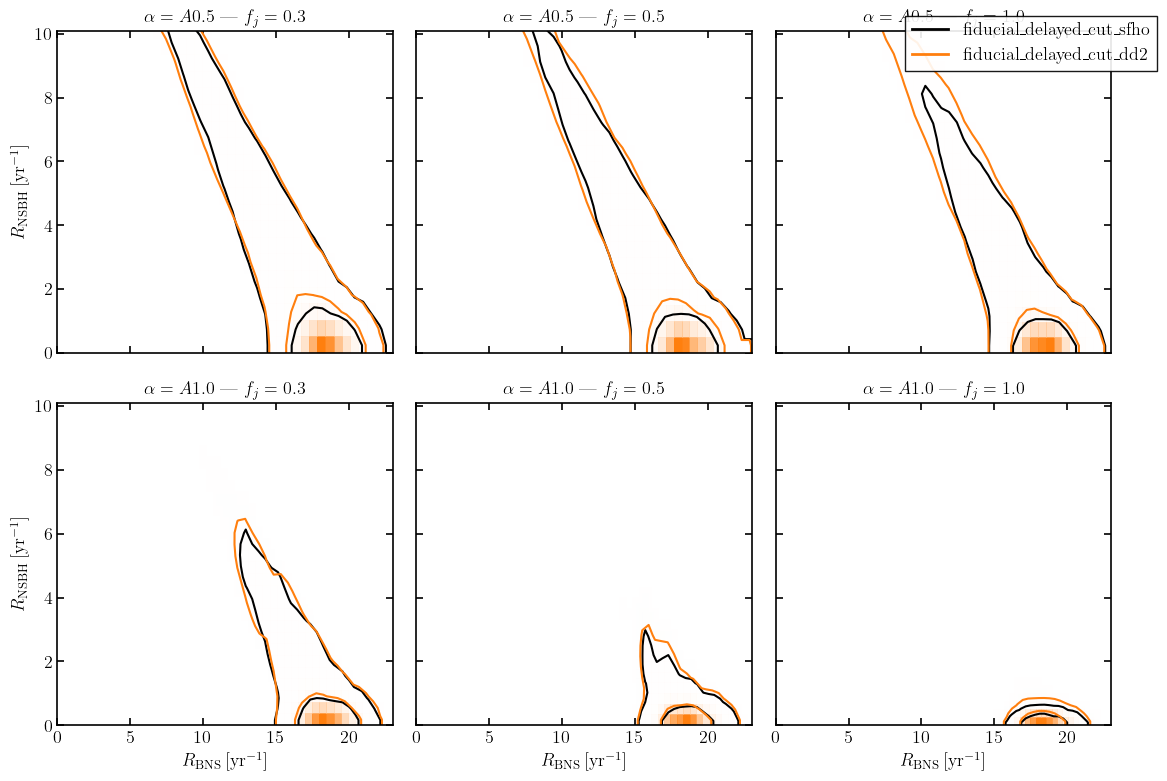

In [ ]:
import corner
import matplotlib.pyplot as plt
import numpy as np

from mcmc_runner_a import draw_grid_samples
from src.nsbh.init import initialize_combined_simulation

def plot_rate_posterior_grid(
    results_by_fj,
    fj_list,
    alpha_list,
    nsbh_populations,
    datafiles,
    swap_axes=False,
    bins=40,
    levels=(0.68, 0.95),
):
    """Plot 2D posterior rate contours in a fj-by-alpha grid."""
    row_values = fj_list if swap_axes else alpha_list
    col_values = alpha_list if swap_axes else fj_list
    rows = len(row_values)
    cols = len(col_values)
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 4 * rows),
        squeeze=False,
        sharex=True,
        sharey=True
    )

    alpha_to_index = {alpha: idx for idx, alpha in enumerate(alpha_list)}
    triggered_years_cache = {}
    population_colors = ["k", "C1", "C2", "C3"]

    for row_idx, row_value in enumerate(row_values):
        for col_idx, col_value in enumerate(col_values):
            alpha = col_value if swap_axes else row_value
            fj = row_value if swap_axes else col_value
            ax = axes[row_idx, col_idx]
            grid_bundle = results_by_fj[fj]
            grid_files_by_population = grid_bundle["grid_files"]

            if alpha not in triggered_years_cache:
                bns_params, _, _ = initialize_combined_simulation(
                    datafiles=datafiles,
                    params={"z_model": f"fiducial_delayed_{alpha}"},
                    nsbh_population=nsbh_populations[0],
                    nsbh_alpha=alpha,
                )
                triggered_years_cache[alpha] = bns_params.triggered_years

            triggered_years = triggered_years_cache[alpha]

            for pop_idx, population in enumerate(nsbh_populations):
                grid_file = grid_files_by_population[pop_idx][alpha_to_index[alpha]]
                _, samples_mu_bns, samples_mu_nsbh = draw_grid_samples(grid_file)
                x = samples_mu_bns / triggered_years
                y = samples_mu_nsbh / triggered_years

                corner.hist2d(
                    x,
                    y,
                    ax=ax,
                    color=population_colors[pop_idx % len(population_colors)],
                    plot_datapoints=False,
                    plot_density=True,
                    no_fill_contours=False,
                    bins=bins,
                    smooth=1,
                    smooth1d=0,
                    levels=list(levels),
                )

            if row_idx == rows - 1:
                ax.set_xlim(0, 23)
                ax.set_xlabel(r"$R_{\rm BNS}\,[\mathrm{yr}^{-1}]$")
            if col_idx == 0:
                ax.set_ylim(0, 23)
                ax.set_ylabel(r"$R_{\rm NSBH}\,[\mathrm{yr}^{-1}]$")

            ax.set_title(f"$\\alpha={alpha}$ | $f_{{j}}={fj}$")

    handles = [
        plt.Line2D(
            [0],
            [0],
            color=population_colors[i],
            lw=2,
            label=nsbh_populations[i],
        )
        for i in range(len(nsbh_populations))
    ]
    fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.98, 0.98))
    fig.tight_layout(rect=(0, 0, 0.95, 1))
    return fig, axes

plot_rate_posterior_grid(
    results_by_fj=results_by_fj,
    fj_list=fj_list,
    alpha_list=possible_alpha,
    nsbh_populations=nsbh_populations,
    datafiles=datafiles,
    swap_axes=False,
)

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 19248.6 yr^-1 (local R_0 = 3.9 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A0.5
  BHNSs local rate R_0 = 3.9 Gpc^-3 yr^-1
  BHNSs total rate     = 19249 yr^-1
  1-year z sample size = 19248
Maximum log-likelihood value: -4.887336044640374
Maximum log-likelihood value: -4.8879908030038255
Maximum log-likelihood value: -4.887333073090058
Maximum log-likelihood value: -4.887995725940394
Maximum log-likelihood value: -4.887333322542627
Maximum log-likelihood value: -4.888007031853116
Using redshift model: samples_fiducial

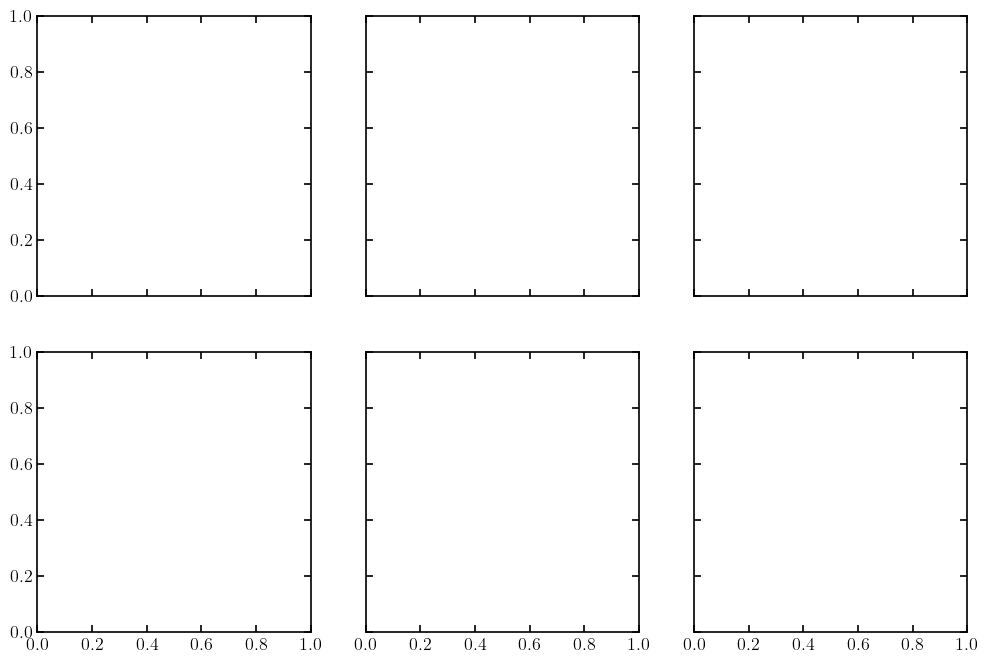

In [13]:
from mcmc_runner_a import draw_grid_samples
from src.nsbh.init import initialize_combined_simulation

def posterior_grid_prep(
    results_by_fj,
    fj_list,
    alpha_list,
    nsbh_populations,
    datafiles,
    swap_axes=False,
    bins=40,
    levels=(0.68, 0.95),
):
    """Plot 2D posterior rate contours in a fj-by-alpha grid."""
    row_values = fj_list if swap_axes else alpha_list
    col_values = alpha_list if swap_axes else fj_list
    rows = len(row_values)
    cols = len(col_values)
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 4 * rows),
        squeeze=False,
        sharex=True,
        sharey=True
    )

    alpha_to_index = {alpha: idx for idx, alpha in enumerate(alpha_list)}
    triggered_years_cache = {}
    population_colors = ["k", "C1", "C2", "C3"]
    dictionary_of_results = {}

    for row_idx, row_value in enumerate(row_values):
        for col_idx, col_value in enumerate(col_values):
            alpha = col_value if swap_axes else row_value
            fj = row_value if swap_axes else col_value
            ax = axes[row_idx, col_idx]
            grid_bundle = results_by_fj[fj]
            grid_files_by_population = grid_bundle["grid_files"]

            if alpha not in triggered_years_cache:
                bns_params, _, _ = initialize_combined_simulation(
                    datafiles=datafiles,
                    params={"z_model": f"fiducial_delayed_{alpha}"},
                    nsbh_population=nsbh_populations[0],
                    nsbh_alpha=alpha,
                )
                triggered_years_cache[alpha] = bns_params.triggered_years

            triggered_years = triggered_years_cache[alpha]



            for pop_idx, population in enumerate(nsbh_populations):
                grid_file = grid_files_by_population[pop_idx][alpha_to_index[alpha]]
                _, samples_mu_bns, samples_mu_nsbh = draw_grid_samples(grid_file)
                x = samples_mu_bns / triggered_years
                y = samples_mu_nsbh / triggered_years
                # save local rates too
                dictionary_of_results[(fj, alpha, population)] = {
                    "R_BNS": x,
                    "R_NSBH": y,
                }

    return dictionary_of_results

dic_in = posterior_grid_prep(
    results_by_fj=results_by_fj,
    fj_list=fj_list,
    alpha_list=possible_alpha,
    nsbh_populations=nsbh_populations,
    datafiles=datafiles,
    swap_axes=False,
    bins=40,
    levels=(0.68, 0.95),
)

(<Figure size 1200x800 with 6 Axes>,
 array([[<Axes: ylabel='$\\eta_{\\rm NSBH}$'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='$\\eta_{\\rm BNS}$', ylabel='$\\eta_{\\rm NSBH}$'>,
         <Axes: xlabel='$\\eta_{\\rm BNS}$'>,
         <Axes: xlabel='$\\eta_{\\rm BNS}$'>]], dtype=object))

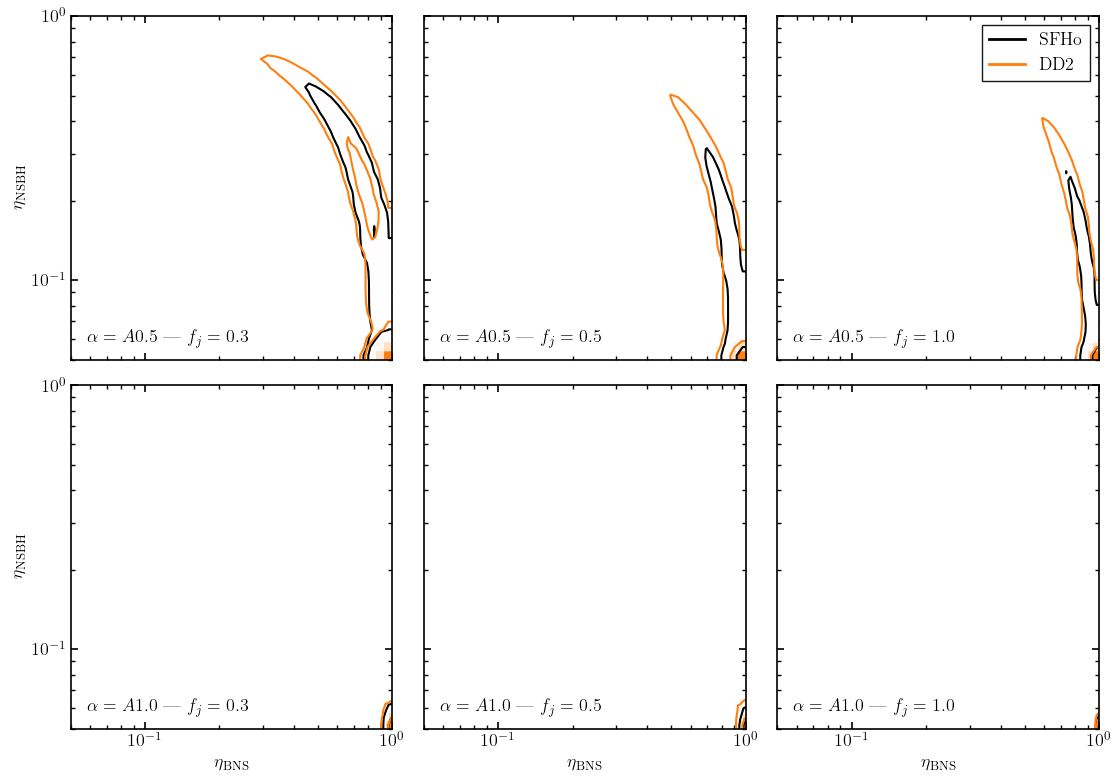

In [14]:
import corner
import matplotlib.pyplot as plt
import numpy as np

def plot_posterior_grid(
        dictionary_of_results,
        fj_list,
        alpha_list,
        nsbh_populations,
        swap_axes=False,
        bins=40,
        levels=(0.68, 0.95),
):
    """Plot 2D posterior rate contours in a fj-by-alpha grid."""
    LOG = True
    x_min = y_min = 0
    if LOG == True: x_min = y_min = 5e-2

    row_values = fj_list if swap_axes else alpha_list
    col_values = alpha_list if swap_axes else fj_list
    rows = len(row_values)
    cols = len(col_values)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 4 * rows),
        squeeze=False,
        sharex=True,
        sharey=True
    )

    population_colors = ["k", "C1", "C2", "C3"]

    for row_idx, row_value in enumerate(row_values):
        for col_idx, col_value in enumerate(col_values):
            alpha = col_value if swap_axes else row_value
            fj = row_value if swap_axes else col_value
            ax = axes[row_idx, col_idx]
            for pop_idx, population in enumerate(nsbh_populations):
                x, y = dictionary_of_results[(fj, alpha, population)]["R_BNS"], dictionary_of_results[(fj, alpha, population)]["R_NSBH"]
                total = x + y
                x = x / total
                y = y / total
                
                if LOG:
                    #clip
                    x = np.clip(x, x_min, 1)
                    y = np.clip(y, y_min, 1)

                corner.hist2d(
                    x,
                    y,
                    ax=ax,
                    color=population_colors[pop_idx % len(population_colors)],
                    plot_datapoints=False,
                    plot_density=True,
                    no_fill_contours=False,
                    bins=bins,
                    smooth=1,
                    smooth1d=0,
                    levels=list(levels),
                    axes_scale=['log', 'log'] if LOG else ['linear', 'linear']
                )
                if LOG == True:
                    ax.set_xscale('log')
                    ax.set_yscale('log')

            if row_idx == rows - 1:
                ax.set_xlim(x_min, 1)
                ax.set_ylim(y_min, 1)
                #ax.set_xlabel(r"$\frac{R_{\rm BNS}^{\rm sGRB}}{R_{\rm BNS}^{\rm sGRB}+R_{\rm NSBH}^{\rm sGRB}}$")
                ax.set_xlabel(r"$\eta_{\rm BNS}$")
            if col_idx == 0:
                ax.set_ylim(y_min, 1)
                ax.set_xlim(x_min, 1)
                #ax.set_ylabel(r"$\frac{R_{\rm NSBH}^{\rm sGRB}}{R_{\rm BNS}^{\rm sGRB}+R_{\rm NSBH}^{\rm sGRB}}$")
                ax.set_ylabel(r"$\eta_{\rm NSBH}$")

            #ax.set_title(f"$\\alpha={alpha}$ | $f_{{j}}={fj}$")
            ax.text(0.05, 0.05, f"$\\alpha={alpha}$ | $f_{{j}}={fj}$", transform=ax.transAxes)

    legend_handles = [
        plt.Line2D([0], [0], color="k", lw=2, label=f"SFHo"),
        plt.Line2D([0], [0], color="C1", lw=2, label=f"DD2")
    ]
    #fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.95, 0.95))
    #add legend to 3rd figure 
    axes[0, 2].legend(handles=legend_handles, loc="upper right")
    
    fig.tight_layout(rect=(0, 0, 0.95, 1))
    return fig, axes

plot_posterior_grid(
    dictionary_of_results=dic_in,
    fj_list=fj_list,
    alpha_list=possible_alpha,
    nsbh_populations=nsbh_populations,
    swap_axes=False,
    bins=40,
    levels=(0.68, 0.95),
)